In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import ast
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from scipy.stats import randint
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor, early_stopping
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.UInt64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)


In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
ain_data = gpd.read_file("../datasets_par_departement/departement-01-ain-original.geojson")
yvelines_data = gpd.read_file("../datasets_par_departement/departement-78-yvelines-original.geojson")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")
doubs_voisins = pd.read_csv("../data/data_train_test/doubs_tous_voisins.csv")
ain_voisins = pd.read_csv("../data/data_train_test/ain_tous_voisins.csv")
yvelines_voisins = pd.read_csv("../data/data_train_test/yvelines_tous_voisins.csv")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

ain_data = calculer_duree(ain_data, 'date_debut', 'date_fin')
ain_data['centroid'] = ain_data.geometry.centroid
ain_data['centroid_lon'] = ain_data['centroid'].x
ain_data['centroid_lat'] = ain_data['centroid'].y
ain_data['date_debut'] = pd.to_datetime(ain_data['date_debut'], errors='coerce')
ain_data['hour'] = ain_data['date_debut'].dt.hour
ain_data['date'] = pd.to_datetime(ain_data['date'], errors='coerce')
ain_data['month'] = ain_data['date'].dt.month
ain_data['weekday'] = ain_data['date'].dt.weekday
ain_data['duree_minutes'] = pd.to_timedelta(ain_data['duree']).dt.total_seconds() / 60

yvelines_data = calculer_duree(yvelines_data, 'date_debut', 'date_fin')
yvelines_data['centroid'] = yvelines_data.geometry.centroid
yvelines_data['centroid_lon'] = yvelines_data['centroid'].x
yvelines_data['centroid_lat'] = yvelines_data['centroid'].y
yvelines_data['date_debut'] = pd.to_datetime(yvelines_data['date_debut'], errors='coerce')
yvelines_data['hour'] = yvelines_data['date_debut'].dt.hour
yvelines_data['date'] = pd.to_datetime(yvelines_data['date'], errors='coerce')
yvelines_data['month'] = yvelines_data['date'].dt.month
yvelines_data['weekday'] = yvelines_data['date'].dt.weekday
yvelines_data['duree_minutes'] = pd.to_timedelta(yvelines_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [5]:
all_data = pd.concat([doubs_data, ain_data, yvelines_data], ignore_index=True)

In [6]:
all_data = all_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(all_data)
all_data.dropna(axis=1, thresh=threshold, inplace=True)

all_data.dropna(inplace=True)

In [7]:
all_data['date'] = pd.to_datetime(all_data['date'])

def get_saison(month):
    if month in [12, 1, 2]:
        return 'Hiver'
    elif month in [3, 4, 5]:
        return 'Printemps'
    elif month in [6, 7, 8]:
        return 'Été'
    else:
        return 'Automne'

all_data['saison'] = all_data['date'].dt.month.apply(get_saison)

all_data['saison_annee'] = all_data['saison'] + ' ' + all_data['date'].dt.year.astype(str)

print(all_data[['date', 'saison', 'saison_annee']].head())

        date   saison  saison_annee
0 2014-10-02  Automne  Automne 2014
1 2014-10-03  Automne  Automne 2014
2 2014-10-04  Automne  Automne 2014
3 2014-10-04  Automne  Automne 2014
4 2014-10-05  Automne  Automne 2014


In [8]:
cols_to_drop = [
    'raison_sortie', 'label', 'duree',
    'index', 'longitude', 'latitude', 'sinister', 'id_caserne', 'date_debut', 'date_fin', 'year', 'scale0', 'hour', 'month', 'weekday', 'distance', 'saison'
]

all_data = all_data.drop(columns=[col for col in cols_to_drop if col in all_data.columns])

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -422.394899   601.022313  37.340677  56.223523  0.102578   
1   2.1  -447.980329   626.607743  38.283164  57.206211  0.084454   
2   2.2  -473.565759   652.193173  38.283164  57.206211  0.084454   
3   2.3  -499.151189   677.778604  37.678803  57.117149  0.087303   
4   2.4  -524.736620   703.364034  37.678803  57.117149  0.087303   
5   2.5  -550.322050   728.949464  39.061472  57.966510  0.059957   
6   2.6  -575.907480   754.534894  40.175270  58.512614  0.042161   
7   2.7  -601.492911   780.120325  40.175270  58.512614  0.042161   
8   2.8  -627.078341   805.705755  40.175270  58.512614  0.042161   
9   2.9  -652.663771   831.291185  40.175270  58.512614  0.042161   
10  3.0  -678.249201   856.876616  41.133564  59.305535  0.016025   
11  3.1  -703.834632   882.462046  38.917777  57.668394  0.101820   
12  3.2  -729.420062   908.047476  41.273456  65.764858  0.048117   
13  3.3  -755.005492   933.632906 

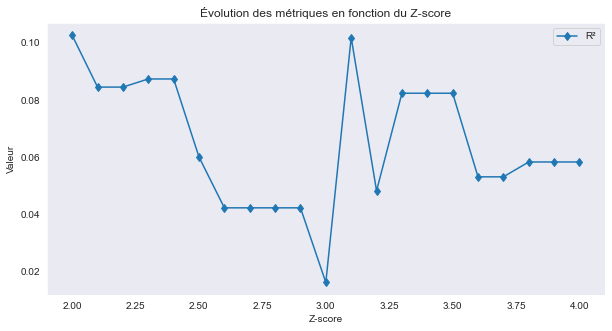

In [9]:
df = all_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'saison_annee', 'departement']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'saison_annee', 'departement']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

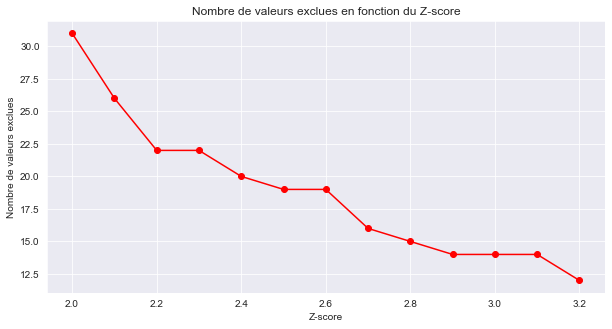

In [10]:
df = doubs_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

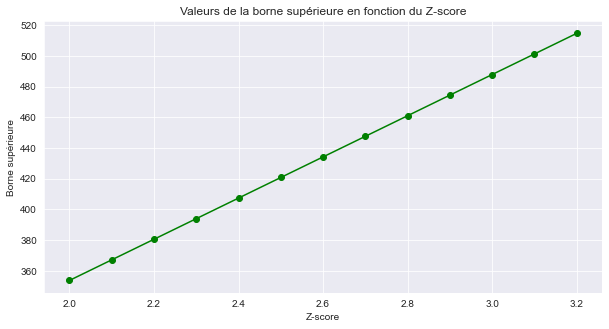

In [11]:
df = doubs_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [12]:
all_data['z_score'] = np.abs(zscore(all_data['duree_minutes']))

all_data_filtered = all_data[all_data['z_score'] <= 3.1].drop(columns=['z_score'])

values_removed = len(all_data) - len(all_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(all_data) * 100:.2f}%")

Nombre de valeurs supprimées : 36
Pourcentage des données supprimées : 0.47%


In [13]:
all_data_filtered.isna().sum()

hex_id                   0
date                     0
departement              0
duree_minutes            0
geometry                 0
centroid                 0
centroid_lon             0
centroid_lat             0
NDVI                     0
NDMI                     0
NDBI                     0
NDSI                     0
NDWI                     0
PasDeRoute               0
motorway                 0
primary                  0
secondary                0
tertiary                 0
path                     0
population               0
elevation                0
foret_encoder            0
highway_encoder          0
PasDeforet               0
Châtaignier              0
Chênes décidus           0
Conifères                0
Douglas                  0
Feuillus                 0
Hêtre                    0
Mixte                    0
Mélèze                   0
NC                       0
NR                       0
Peuplier                 0
Pin autre                0
Pin laricio, pin noir    0
P

In [14]:
cols_a_conserver = ['hex_id', 'geometry', 'centroid', 'saison_annee', 'departement']

all_data_moy = all_data_filtered.groupby(['hex_id', 'saison_annee'], as_index=False).mean(numeric_only=True)

all_data_conserve = all_data_filtered[cols_a_conserver].drop_duplicates(subset=['hex_id', 'saison_annee'])

all_data_final = pd.merge(all_data_moy, all_data_conserve, on=['hex_id', 'saison_annee'], how='left')

print(all_data_final.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
1  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   
2  871f80492ffffff  Printemps 2023      72.083333      6.350198     47.477082   
3  871f80492ffffff        Été 2015      40.850000      6.350198     47.477082   
4  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...      grass     crops  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  25.637803  0.062838   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  25.637803  0.062838   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  25.637803  0.062838   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  25.637803  0.062838   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  25.637803  0.062838   

      shrub  flooded     built  

In [15]:
duree_stats = all_data_filtered.groupby(['hex_id', 'saison_annee'])['duree_minutes'].agg(
    duree_minutes_max='max',
    duree_minutes_med='median'
).reset_index()

all_data_final = pd.merge(all_data_final, duree_stats, on=['hex_id', 'saison_annee'], how='left')

print(all_data_final.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
1  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   
2  871f80492ffffff  Printemps 2023      72.083333      6.350198     47.477082   
3  871f80492ffffff        Été 2015      40.850000      6.350198     47.477082   
4  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...     shrub  flooded  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  4.700264      0.0   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  4.700264      0.0   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  4.700264      0.0   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  4.700264      0.0   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  4.700264      0.0   

      built  bare  snow                     

In [16]:
ordre_saisons = {'Hiver': 1, 'Printemps': 2, 'Été': 3, 'Automne': 4}

all_data_final[['Saison', 'Annee']] = all_data_final['saison_annee'].str.split(' ', expand=True)
all_data_final['Annee'] = all_data_final['Annee'].astype(int)
all_data_final['Saison_ordre'] = all_data_final['Saison'].map(ordre_saisons)

all_data_final = all_data_final.sort_values(by=['hex_id', 'Annee', 'Saison_ordre'])

all_data_final['moyenne_duree_hex_id'] = (
    all_data_final.groupby('hex_id')['duree_minutes']
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

all_data_final['moyenne_duree_hex_id'].fillna(0, inplace=True)

all_data_final.drop(columns=['Saison', 'Annee', 'Saison_ordre'], inplace=True)

In [17]:
test_size = 0.2
random_state = 42
hex_ids = all_data_final["hex_id"].unique()
splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(splitter.split(hex_ids, groups=hex_ids))
train_hex = hex_ids[train_idx]
test_hex = hex_ids[test_idx]
all_train = all_data_final[all_data_final["hex_id"].isin(train_hex)]
all_test = all_data_final[all_data_final["hex_id"].isin(test_hex)]
print(f"Taille du train : {all_train.shape[0]} lignes")
print(f"Taille du test : {all_test.shape[0]} lignes")

Taille du train : 4479 lignes
Taille du test : 1172 lignes


In [18]:
common_hex = set(all_train["hex_id"]).intersection(set(all_test["hex_id"]))
if common_hex:
    print(f"Problème : {len(common_hex)} hex_id sont présents dans les deux datasets.")
else:
    print("Vérification réussie : Aucun hex_id en commun entre train et test.")

Vérification réussie : Aucun hex_id en commun entre train et test.


In [19]:
all_voisins = pd.concat([doubs_voisins, ain_voisins, yvelines_voisins], ignore_index=True)

all_train = all_train.merge(all_voisins[['hex_id', 'hex_voisins']], on='hex_id', how='left')
all_test = all_test.merge(all_voisins[['hex_id', 'hex_voisins']], on='hex_id', how='left')

In [20]:
all_train['hex_voisins'] = all_train['hex_voisins'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
all_test['hex_voisins'] = all_test['hex_voisins'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

print(all_train['hex_voisins'].head())
print(all_test['hex_voisins'].head())

0    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
1    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
2    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
3    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
4    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
Name: hex_voisins, dtype: object
0    [871f82b49ffffff, 871f82b4bffffff, 871f82a65ff...
1    [871f82b49ffffff, 871f82b4bffffff, 871f82a65ff...
2    [871f82b49ffffff, 871f82b4bffffff, 871f82a65ff...
3    [871f82b49ffffff, 871f82b4bffffff, 871f82a65ff...
4    [871f82b49ffffff, 871f82b4bffffff, 871f82a65ff...
Name: hex_voisins, dtype: object


In [21]:
all_train = all_train.dropna()
all_test = all_test.dropna()

In [22]:
def calculer_statistiques(row, train_data):
    hex_cible = row['hex_id']
    saison_actuelle = row['saison_annee']

    hex_voisins = row['hex_voisins']

    hex_ids_a_prendre = [hex_cible] + hex_voisins
    data_filtree = train_data[train_data['hex_id'].isin(hex_ids_a_prendre)]

    data_filtree = data_filtree[data_filtree['saison_annee'] < saison_actuelle]

    if data_filtree.empty:
        return pd.Series([np.nan] * 7,
                         index=['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                                'duree_min', 'duree_max', 'duree_q1', 'duree_q3'])

    duree_moyenne = data_filtree['duree_minutes'].mean()
    duree_mediane = data_filtree['duree_minutes'].median()
    duree_ecart_type = data_filtree['duree_minutes'].std()
    duree_min = data_filtree['duree_minutes'].min()
    duree_max = data_filtree['duree_minutes'].max()
    duree_q1 = data_filtree['duree_minutes'].quantile(0.25)
    duree_q3 = data_filtree['duree_minutes'].quantile(0.75)

    return pd.Series([duree_moyenne, duree_mediane, duree_ecart_type,
                      duree_min, duree_max, duree_q1, duree_q3],
                     index=['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                            'duree_min', 'duree_max', 'duree_q1', 'duree_q3'])

all_train[['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
             'duree_min', 'duree_max', 'duree_q1', 'duree_q3']] = all_train.apply(
    lambda row: calculer_statistiques(row, all_data_final), axis=1)

all_test[['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
            'duree_min', 'duree_max', 'duree_q1', 'duree_q3']] = all_test.apply(
    lambda row: calculer_statistiques(row, all_data_final), axis=1)

print(all_train.head())
print(all_test.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff        Été 2015      40.850000      6.350198     47.477082   
1  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   
2  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
3  871f80492ffffff        Été 2019     168.250000      6.350198     47.477082   
4  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...  duree_minutes_med  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...          40.850000   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...         197.783333   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...         163.133333   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...         168.250000   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...          61.850000   

   moyenne_duree_hex_id                     

In [23]:
colonnes_statistiques = ['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                         'duree_min', 'duree_max', 'duree_q1', 'duree_q3']

all_train[colonnes_statistiques] = all_train[colonnes_statistiques].fillna(0)
all_test[colonnes_statistiques] = all_test[colonnes_statistiques].fillna(0)

print(all_train.head())
print(all_test.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff        Été 2015      40.850000      6.350198     47.477082   
1  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   
2  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
3  871f80492ffffff        Été 2019     168.250000      6.350198     47.477082   
4  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...  duree_minutes_med  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...          40.850000   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...         197.783333   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...         163.133333   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...         168.250000   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...          61.850000   

   moyenne_duree_hex_id                     

In [24]:
features = [col for col in all_train.columns if col not in ['duree_minutes', 'duree_minutes_max', 'duree_minutes_med','hex_id', 'geometry', 'centroid', 'saison_annee', 'hex_voisins', 'id_compagnies']]

X_train = all_train[features]
y_train = all_train[['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']]

X_test = all_test[features]
y_test = all_test[['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ])

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

for i, target in enumerate(['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    print(f"Résultats pour {target} :")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print("-" * 40)

Résultats pour duree_minutes :
  MAE  : 41.7660
  MSE  : 3603.1172
  RMSE : 60.03
  R²   : 0.0842
----------------------------------------
Résultats pour duree_minutes_max :
  MAE  : 48.0142
  MSE  : 5272.1939
  RMSE : 72.61
  R²   : 0.0298
----------------------------------------
Résultats pour duree_minutes_med :
  MAE  : 41.0930
  MSE  : 3513.5582
  RMSE : 59.28
  R²   : 0.0948
----------------------------------------


In [25]:
targets = ['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']

log_y_train = np.log(y_train[targets])
log_y_test = np.log(y_test[targets])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in X_train.columns if col != 'departement'])
    ])

rf_model_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)))
])

rf_model_log.fit(X_train, log_y_train)

log_y_pred = rf_model_log.predict(X_test)
y_pred = np.exp(log_y_pred)

r2_scores_log = {target: r2_score(y_test[target], y_pred[:, i]) for i, target in enumerate(targets)}

print("R² avec transformation logarithmique :")
for target, r2 in r2_scores_log.items():
    print(f"{target}: {r2:.4f}")

R² avec transformation logarithmique :
duree_minutes: 0.0645
duree_minutes_max: 0.0165
duree_minutes_med: 0.0672


In [26]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)))
])

rf_model.fit(X_train, y_train[targets])

y_pred = rf_model.predict(X_test)

r2_scores = {target: r2_score(y_test[target], y_pred[:, i]) for i, target in enumerate(targets)}

print("R² sans transformation logarithmique :")
for target, r2 in r2_scores.items():
    print(f"{target}: {r2:.4f}")

R² sans transformation logarithmique :
duree_minutes: 0.0842
duree_minutes_max: 0.0298
duree_minutes_med: 0.0948


In [27]:
print("Dimensions des datasets :")
print(f"X_train : {X_train.shape}, X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}, y_test : {y_test.shape}\n")

print("Aperçu de X_train :")
print(X_train.head(), "\n")

print("Aperçu de y_train :")
print(y_train.head(), "\n")

print("Statistiques descriptives des cibles :")
print(y_train.describe(), "\n")

print("Quartiles des cibles :")
print(y_train.quantile([0.25, 0.5, 0.75]).T, "\n")

print("Valeurs minimales et maximales :")
print(y_train.agg(["min", "max"]).T, "\n")

Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
outliers = ((y_train < (Q1 - 1.5 * IQR)) | (y_train > (Q3 + 1.5 * IQR))).sum()
print("Nombre d'outliers détectés par variable cible :")
print(outliers, "\n")

print("Top 10 des corrélations entre features et duree_minutes_med :")
print(X_train.corrwith(y_train["duree_minutes_med"]).abs().sort_values(ascending=False).head(10), "\n")

missing_values_X = X_train.isnull().sum()
missing_values_y = y_train.isnull().sum()
print("Nombre de valeurs manquantes (X_train) :")
print(missing_values_X[missing_values_X > 0], "\n")

print("Nombre de valeurs manquantes (y_train) :")
print(missing_values_y[missing_values_y > 0], "\n")

print("Nombre de variables par type :")
print(X_train.dtypes.value_counts(), "\n")

print("Liste des variables numériques :")
print(X_train.select_dtypes(include=['number']).columns.tolist(), "\n")

print("Liste des variables catégorielles :")
print(X_train.select_dtypes(exclude=['number']).columns.tolist(), "\n")

Dimensions des datasets :
X_train : (4454, 54), X_test : (1168, 54)
y_train : (4454, 3), y_test : (1168, 3)

Aperçu de X_train :
   centroid_lon  centroid_lat      NDVI      NDMI      NDBI     NDSI  \
0      6.350198     47.477082  0.720443  0.145452 -0.145452 -0.59362   
1      6.350198     47.477082  0.720443  0.145452 -0.145452 -0.59362   
2      6.350198     47.477082  0.720443  0.145452 -0.145452 -0.59362   
3      6.350198     47.477082  0.720443  0.145452 -0.145452 -0.59362   
4      6.350198     47.477082  0.720443  0.145452 -0.145452 -0.59362   

       NDWI  PasDeRoute  motorway   primary  ...  snow           departement  \
0 -0.672639   96.116627       0.0  0.703783  ...   0.0  departement-25-doubs   
1 -0.672639   96.116627       0.0  0.703783  ...   0.0  departement-25-doubs   
2 -0.672639   96.116627       0.0  0.703783  ...   0.0  departement-25-doubs   
3 -0.672639   96.116627       0.0  0.703783  ...   0.0  departement-25-doubs   
4 -0.672639   96.116627       0.0  0.7

In [28]:
print("Valeurs manquantes dans X_train :")
print(X_train.isnull().sum())

print("\nValeurs manquantes dans X_test :")
print(X_test.isnull().sum())

print("\nValeurs manquantes dans y_train :")
print(y_train.isnull().sum())

print("\nValeurs manquantes dans y_test :")
print(y_test.isnull().sum())

Valeurs manquantes dans X_train :
centroid_lon             0
centroid_lat             0
NDVI                     0
NDMI                     0
NDBI                     0
NDSI                     0
NDWI                     0
PasDeRoute               0
motorway                 0
primary                  0
secondary                0
tertiary                 0
path                     0
population               0
elevation                0
foret_encoder            0
highway_encoder          0
PasDeforet               0
Châtaignier              0
Chênes décidus           0
Conifères                0
Douglas                  0
Feuillus                 0
Hêtre                    0
Mixte                    0
Mélèze                   0
NC                       0
NR                       0
Peuplier                 0
Pin autre                0
Pin laricio, pin noir    0
Pin maritime             0
Pin sylvestre            0
Pins mélangés            0
Robinier                 0
Sapin, épicéa        

In [29]:
def limit_outliers(df, lower_percentile=1, upper_percentile=99):
    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        lower = df[col].quantile(lower_percentile / 100)
        upper = df[col].quantile(upper_percentile / 100)
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df

X_train = limit_outliers(X_train)
X_test = limit_outliers(X_test)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['departement']),
        ('num', StandardScaler(), [col for col in X_train.columns if col != 'departement'])
    ])

In [31]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)))
])

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['departement']),
                                                 ('num', StandardScaler(),
                                                  ['centroid_lon',
                                                   'centroid_lat', 'NDVI',
                                                   'NDMI', 'NDBI', 'NDSI',
                                                   'NDWI', 'PasDeRoute',
                                                   'motorway', 'primary',
                                                   'secondary', 'tertiary',
                                                   'path', 'population',
                                                   'elevation', 'foret_encoder',
                                                   'highway_encoder',
                                                   'PasDeforet', 'Châtaignier',
                                                   'Chênes décidus',
                                                   'Conifères', 'Douglas',
                                                   'Feuillus', 'Hêtre', 'Mixte',
                                                   'Mélèze', 'NC', 'NR',
                                                   'Peuplier', 'Pin autre', ...])])),
                ('regressor',
                 MultiOutputRegressor(estimator=RandomForestRegressor(n_jobs=-1,
                                                                      random_state=42)))])

In [32]:
X_train_transformed = preprocessor.transform(X_train)
print("Aperçu de X_train après transformation :")
print(X_train_transformed[:5, :])

Aperçu de X_train après transformation :
[[ 0.          1.          0.          0.90076847  0.15089869  0.87881565
   0.31196411 -0.31196411 -1.07394341 -0.85006976  0.39713516 -0.35868042
   0.14902611 -0.77175475  0.91530148 -0.56275164 -0.44270177 -0.45810337
  -0.33557985  0.          0.2525403  -0.23502957 -0.31970347 -0.23622426
  -0.19684093  1.03251266 -0.56858199 -0.46057952 -0.11624046 -0.29014983
  -0.45914288 -0.21522771  0.         -0.1752306   0.         -0.22243532
  -0.12807218 -0.16927504 -0.32577983 -0.40952546  0.04355233  3.61569195
  -0.7726771  -0.45277309 -0.67090237 -0.7789509  -0.25151716  0.
  -1.2302794   0.3536364   0.16024527  0.0744618   0.10769229 -0.17912042
   0.42050945  0.4884777 ]
 [ 0.          1.          0.          0.90076847  0.15089869  0.87881565
   0.31196411 -0.31196411 -1.07394341 -0.85006976  0.39713516 -0.35868042
   0.14902611 -0.77175475  0.91530148 -0.56275164 -0.44270177 -0.45810337
  -0.33557985  0.          0.2525403  -0.23502957 -0

In [33]:
model_pipeline.fit(X_train, y_train)

y_train_pred = model_pipeline.predict(X_train)

y_test_pred = model_pipeline.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)

r2_test = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred)

print(f"R² sur les données d'entraînement : {r2_train:.4f}")
print(f"R² sur les données de test : {r2_test:.4f}")
print(f"MSE sur les données d'entraînement : {mse_train:.4f}")
print(f"MSE sur les données de test : {mse_test:.4f}")

R² sur les données d'entraînement : 0.8609
R² sur les données de test : 0.0783
MSE sur les données d'entraînement : 625.0206
MSE sur les données de test : 4090.1854


In [34]:
param_dist = {
    'regressor__estimator__n_estimators': randint(50, 200),
    'regressor__estimator__max_depth': randint(5, 30),
    'regressor__estimator__min_samples_split': randint(2, 10),
    'regressor__estimator__min_samples_leaf': randint(1, 10),
    'regressor__estimator__max_features': ['auto', 'sqrt', 'log2']
}

random_search = RandomizedSearchCV(model_pipeline, param_distributions=param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)

random_search.fit(X_train, y_train)

print(f"Meilleurs hyperparamètres : {random_search.best_params_}")

y_train_pred_opt = random_search.predict(X_train)
y_test_pred_opt = random_search.predict(X_test)

r2_train_opt = r2_score(y_train, y_train_pred_opt)
r2_test_opt = r2_score(y_test, y_test_pred_opt)

print(f"R² optimisé sur les données d'entraînement : {r2_train_opt:.4f}")
print(f"R² optimisé sur les données de test : {r2_test_opt:.4f}")

Meilleurs hyperparamètres : {'regressor__estimator__max_depth': 11, 'regressor__estimator__max_features': 'sqrt', 'regressor__estimator__min_samples_leaf': 3, 'regressor__estimator__min_samples_split': 8, 'regressor__estimator__n_estimators': 124}
R² optimisé sur les données d'entraînement : 0.4207
R² optimisé sur les données de test : 0.1177


In [35]:
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = ['departement']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', MultiOutputRegressor(XGBRegressor(objective="reg:squarederror",
             max_depth=7,
             min_samples_leaf=10,
             min_samples_split=12,
             n_estimators=80,
             reg_lambda=10,
             reg_alpha=2,
             random_state=42)
))
])

xgb_model.fit(X_train, y_train)

y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred, multioutput='raw_values')
r2_test = r2_score(y_test, y_test_pred, multioutput='raw_values')

mse_train = mean_squared_error(y_train, y_train_pred, multioutput='raw_values')
mse_test = mean_squared_error(y_test, y_test_pred, multioutput='raw_values')

print(f"R² sur les données d'entraînement : {r2_train.mean():.4f}")
print(f"R² sur les données de test : {r2_test.mean():.4f}")
print(f"MSE sur les données d'entraînement : {mse_train.mean():.4f}")
print(f"MSE sur les données de test : {mse_test.mean():.4f}")

for i, target in enumerate(['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']):
    print(f"\n{target}:")
    print(f"  R² entraînement: {r2_train[i]:.4f}")
    print(f"  R² test: {r2_test[i]:.4f}")
    print(f"  MSE entraînement: {mse_train[i]:.4f}")
    print(f"  MSE test: {mse_test[i]:.4f}")

[13:43:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

[13:43:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

[13:43:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.



R² sur les données d'entraînement : 0.9034
R² sur les données de test : -0.0107
MSE sur les données d'entraînement : 436.6132
MSE sur les données de test : 4466.0355

duree_minutes:
  R² entraînement: 0.9077
  R² test: 0.0006
  MSE entraînement: 384.1587
  MSE test: 3931.9026

duree_minutes_max:
  R² entraînement: 0.8934
  R² test: -0.0152
  MSE entraînement: 545.5737
  MSE test: 5516.6726

duree_minutes_med:
  R² entraînement: 0.9089
  R² test: -0.0175
  MSE entraînement: 380.1071
  MSE test: 3949.5313


In [36]:
print(y_train.shape)
print(y_test.shape)
print(X_train.shape)
print(X_test.shape)

(4454, 3)
(1168, 3)
(4454, 54)
(1168, 54)


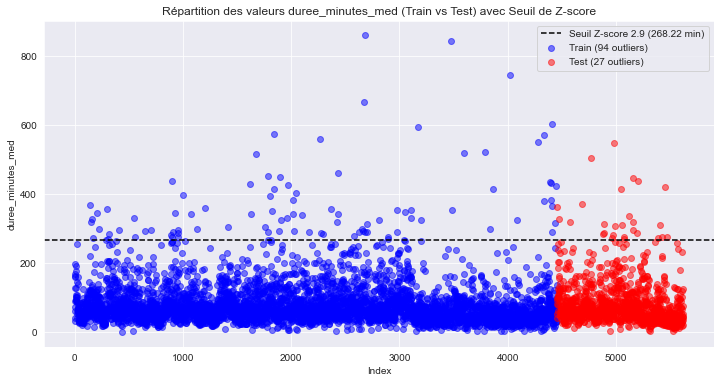

Nombre de valeurs au-delà du seuil (2.9 Z-score) :
  ➡ Train : 94
  ➡ Test  : 27


In [37]:
from scipy.stats import zscore
import matplotlib.pyplot as plt
import numpy as np

all_values = np.concatenate([y_train['duree_minutes_med'], y_test['duree_minutes_med']])
z_scores = zscore(all_values)

seuil_z = 2.9
seuil_val = all_values[np.abs(z_scores) > seuil_z].min()

train_z_scores = z_scores[:len(y_train)]
test_z_scores = z_scores[len(y_train):]

train_outliers = np.sum(np.abs(train_z_scores) > seuil_z)
test_outliers = np.sum(np.abs(test_z_scores) > seuil_z)

train_idx = np.arange(len(y_train))
test_idx = np.arange(len(y_test)) + len(y_train)

plt.figure(figsize=(12, 6))
plt.scatter(train_idx, y_train['duree_minutes_med'], color="blue", alpha=0.5, label=f"Train ({train_outliers} outliers)")
plt.scatter(test_idx, y_test['duree_minutes_med'], color="red", alpha=0.5, label=f"Test ({test_outliers} outliers)")

plt.axhline(y=seuil_val, color="black", linestyle="--", label=f"Seuil Z-score {seuil_z} ({seuil_val:.2f} min)")

plt.xlabel("Index")
plt.ylabel("duree_minutes_med")
plt.title("Répartition des valeurs duree_minutes_med (Train vs Test) avec Seuil de Z-score")
plt.legend()
plt.show()

print(f"Nombre de valeurs au-delà du seuil ({seuil_z} Z-score) :")
print(f"  ➡ Train : {train_outliers}")
print(f"  ➡ Test  : {test_outliers}")

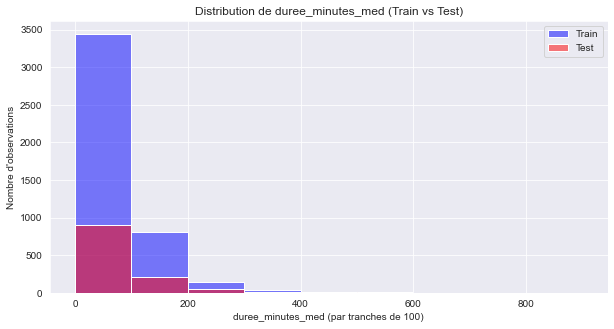

In [38]:
plt.figure(figsize=(10, 5))
bins = np.arange(0, y_train['duree_minutes_med'].max() + 100, 100)  # Tranches de 100

sns.histplot(y_train['duree_minutes_med'], bins=bins, color="blue", alpha=0.5, label="Train")
sns.histplot(y_test['duree_minutes_med'], bins=bins, color="red", alpha=0.5, label="Test")

plt.xlabel("duree_minutes_med (par tranches de 100)")
plt.ylabel("Nombre d'observations")
plt.title("Distribution de duree_minutes_med (Train vs Test)")
plt.legend()
plt.show()

In [39]:
from scipy.stats import zscore

z_scores_train = zscore(y_train['duree_minutes_med'])

seuil_z = 2.9

train_mask = np.abs(z_scores_train) <= seuil_z

X_train_z = X_train[train_mask]
y_train_z = y_train[train_mask]

X_test_z = X_test
y_test_z = y_test

print(f"Taille originale de X_train : {X_train.shape}")
print(f"Taille filtrée de X_train_z : {X_train_z.shape}")

print(f"Taille originale de y_train : {y_train.shape}")
print(f"Taille filtrée de y_train_z : {y_train_z.shape}")

Taille originale de X_train : (4454, 54)
Taille filtrée de X_train_z : (4360, 54)
Taille originale de y_train : (4454, 3)
Taille filtrée de y_train_z : (4360, 3)


In [40]:
num_features = X_train_z.drop(columns=['departement']).columns.tolist()
cat_features = ['departement']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=124,
        max_depth=11,
        max_features='sqrt',
        min_samples_leaf=3,
        min_samples_split=8,
        random_state=42
    ))
])

model.fit(X_train_z, y_train_z)

y_train_pred = model.predict(X_train_z)
y_test_pred = model.predict(X_test_z)

r2_train = r2_score(y_train_z, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train_z, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"R² sur les données d'entraînement : {r2_train:.4f}")
print(f"R² sur les données de test : {r2_test:.4f}")
print(f"MSE sur les données d'entraînement : {mse_train:.4f}")
print(f"MSE sur les données de test : {mse_test:.4f}")

R² sur les données d'entraînement : 0.4467
R² sur les données de test : 0.1075
MSE sur les données d'entraînement : 1306.6670
MSE sur les données de test : 3959.9343


In [41]:
num_features = X_train.drop(columns=['departement']).columns.tolist()
cat_features = ['departement']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=124,
        max_depth=11,
        max_features='sqrt',
        min_samples_leaf=3,
        min_samples_split=8,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"R² sur les données d'entraînement : {r2_train:.4f}")
print(f"R² sur les données de test : {r2_test:.4f}")
print(f"MSE sur les données d'entraînement : {mse_train:.4f}")
print(f"MSE sur les données de test : {mse_test:.4f}")

R² sur les données d'entraînement : 0.4167
R² sur les données de test : 0.1208
MSE sur les données d'entraînement : 2624.1924
MSE sur les données de test : 3902.6999


In [42]:
num_features = X_train.drop(columns=['departement']).columns.tolist()
cat_features = ['departement']

preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=124,
        max_depth=11,
        max_features='sqrt',
        min_samples_leaf=3,
        min_samples_split=8,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"R² sur les données d'entraînement : {r2_train:.4f}")
print(f"R² sur les données de test : {r2_test:.4f}")
print(f"MSE sur les données d'entraînement : {mse_train:.4f}")
print(f"MSE sur les données de test : {mse_test:.4f}")

R² sur les données d'entraînement : 0.4158
R² sur les données de test : 0.1237
MSE sur les données d'entraînement : 2628.3107
MSE sur les données de test : 3889.6560


In [43]:
num_features = X_train.drop(columns=['departement']).columns.tolist()
cat_features = ['departement']

preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

rf = RandomForestRegressor(random_state=42)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', rf)
])

param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [10, 15, 20],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 3, 5],
    'regressor__max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    model, param_grid, cv=3, scoring='r2',
    n_jobs=-1, verbose=2
)

grid_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_search.best_params_)
print("Meilleur score R² (val. croisée) :", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_test_pred = best_model.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"R² sur le test après optimisation : {r2_test:.4f}")
print(f"MSE sur le test après optimisation : {mse_test:.4f}")

Fitting 3 folds for each of 162 candidates, totalling 486 fits
Meilleurs hyperparamètres : {'regressor__max_depth': 10, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}
Meilleur score R² (val. croisée) : 0.037092327820523
R² sur le test après optimisation : 0.1208
MSE sur le test après optimisation : 3902.4296


In [44]:
num_features = X_train_z.columns.tolist()
num_features.remove('departement')
cat_features = ['departement']

preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    ))
])

model.fit(X_train_z, y_train_z)

y_train_pred = model.predict(X_train_z)
y_test_pred = model.predict(X_test_z)

r2_train = r2_score(y_train_z, y_train_pred)
r2_test = r2_score(y_test_z, y_test_pred)
mse_train = mean_squared_error(y_train_z, y_train_pred)
mse_test = mean_squared_error(y_test_z, y_test_pred)

print(f"R² sur les données d'entraînement : {r2_train:.4f}")
print(f"R² sur les données de test : {r2_test:.4f}")
print(f"MSE sur les données d'entraînement : {mse_train:.4f}")
print(f"MSE sur les données de test : {mse_test:.4f}")

R² sur les données d'entraînement : 0.6800
R² sur les données de test : 0.0806
MSE sur les données d'entraînement : 753.7926
MSE sur les données de test : 4088.9679


In [45]:
"""model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ))
])

param_grid_fine = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__subsample': [0.7, 0.9],
    'regressor__colsample_bytree': [0.7, 0.9],
    'regressor__reg_lambda': [1, 5],
    'regressor__reg_alpha': [0.1, 1],
    'regressor__booster': ['gbtree', 'dart']
}

grid_search_fine = GridSearchCV(
    model,
    param_grid_fine,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_search_fine.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_search_fine.best_params_)

best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"R² train : {r2_train:.4f}")
print(f"R² test : {r2_test:.4f}")
print(f"MSE train : {mse_train:.4f}")
print(f"MSE test : {mse_test:.4f}")"""

'model = Pipeline([\n    (\'preprocessor\', preprocessor),\n    (\'regressor\', XGBRegressor(\n        objective=\'reg:squarederror\',\n        random_state=42\n    ))\n])\n\nparam_grid_fine = {\n    \'regressor__n_estimators\': [100, 200],\n    \'regressor__max_depth\': [3, 5],\n    \'regressor__learning_rate\': [0.01, 0.05, 0.1],\n    \'regressor__subsample\': [0.7, 0.9],\n    \'regressor__colsample_bytree\': [0.7, 0.9],\n    \'regressor__reg_lambda\': [1, 5],\n    \'regressor__reg_alpha\': [0.1, 1],\n    \'regressor__booster\': [\'gbtree\', \'dart\']\n}\n\ngrid_search_fine = GridSearchCV(\n    model,\n    param_grid_fine,\n    cv=3,\n    scoring=\'r2\',\n    verbose=1,\n    n_jobs=-1\n)\n\ngrid_search_fine.fit(X_train, y_train)\n\nprint("Meilleurs hyperparamètres :", grid_search_fine.best_params_)\n\nbest_model = grid_search.best_estimator_\n\ny_train_pred = best_model.predict(X_train)\ny_test_pred = best_model.predict(X_test)\n\nr2_train = r2_score(y_train, y_train_pred)\nr2_test =

In [46]:
"""Fitting 3 folds for each of 384 candidates, totalling 1152 fits
Meilleurs hyperparamètres : {'regressor__booster': 'gbtree', 'regressor__colsample_bytree': 0.7, 'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 200, 'regressor__reg_alpha': 1, 'regressor__reg_lambda': 5, 'regressor__subsample': 0.7}
R² train : 0.1343
R² test : 0.1153
MSE train : 3890.5251
MSE test : 3925.8504"""

"Fitting 3 folds for each of 384 candidates, totalling 1152 fits\nMeilleurs hyperparamètres : {'regressor__booster': 'gbtree', 'regressor__colsample_bytree': 0.7, 'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 200, 'regressor__reg_alpha': 1, 'regressor__reg_lambda': 5, 'regressor__subsample': 0.7}\nR² train : 0.1343\nR² test : 0.1153\nMSE train : 3890.5251\nMSE test : 3925.8504"

In [47]:
"""y_train_single = y_train['duree_minutes_med']
y_test_single = y_test['duree_minutes_med']

num_features = X_train.drop(columns=['departement']).columns.tolist()
cat_features = ['departement']

preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [3, 5, 7],
    'regressor__num_leaves': [20, 31, 40],
    'regressor__colsample_bytree': [0.7, 0.9],
    'regressor__subsample': [0.7, 0.9],
    'regressor__reg_alpha': [0, 1],
    'regressor__reg_lambda': [1, 5]
}

grid_search = GridSearchCV(model, param_grid, cv=3, scoring='r2', verbose=3, n_jobs=-1)
grid_search.fit(X_train, y_train_single)

best_params = grid_search.best_params_
print("Meilleurs hyperparamètres :", best_params)

best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

r2_train = r2_score(y_train_single, y_train_pred)
r2_test = r2_score(y_test_single, y_test_pred)
mse_train = mean_squared_error(y_train_single, y_train_pred)
mse_test = mean_squared_error(y_test_single, y_test_pred)

print(f"R² train : {r2_train:.4f}")
print(f"R² test : {r2_test:.4f}")
print(f"MSE train : {mse_train:.4f}")
print(f"MSE test : {mse_test:.4f}")"""

'y_train_single = y_train[\'duree_minutes_med\']\ny_test_single = y_test[\'duree_minutes_med\']\n\nnum_features = X_train.drop(columns=[\'departement\']).columns.tolist()\ncat_features = [\'departement\']\n\npreprocessor = ColumnTransformer([\n    (\'num\', MinMaxScaler(), num_features),\n    (\'cat\', OneHotEncoder(handle_unknown=\'ignore\'), cat_features)\n])\n\nmodel = Pipeline([\n    (\'preprocessor\', preprocessor),\n    (\'regressor\', LGBMRegressor(random_state=42))\n])\n\nparam_grid = {\n    \'regressor__n_estimators\': [100, 200],\n    \'regressor__learning_rate\': [0.01, 0.05, 0.1],\n    \'regressor__max_depth\': [3, 5, 7],\n    \'regressor__num_leaves\': [20, 31, 40],\n    \'regressor__colsample_bytree\': [0.7, 0.9],\n    \'regressor__subsample\': [0.7, 0.9],\n    \'regressor__reg_alpha\': [0, 1],\n    \'regressor__reg_lambda\': [1, 5]\n}\n\ngrid_search = GridSearchCV(model, param_grid, cv=3, scoring=\'r2\', verbose=3, n_jobs=-1)\ngrid_search.fit(X_train, y_train_single)\n\n

Dataset has 0 variance; skipping density estimate.
Dataset has 0 variance; skipping density estimate.


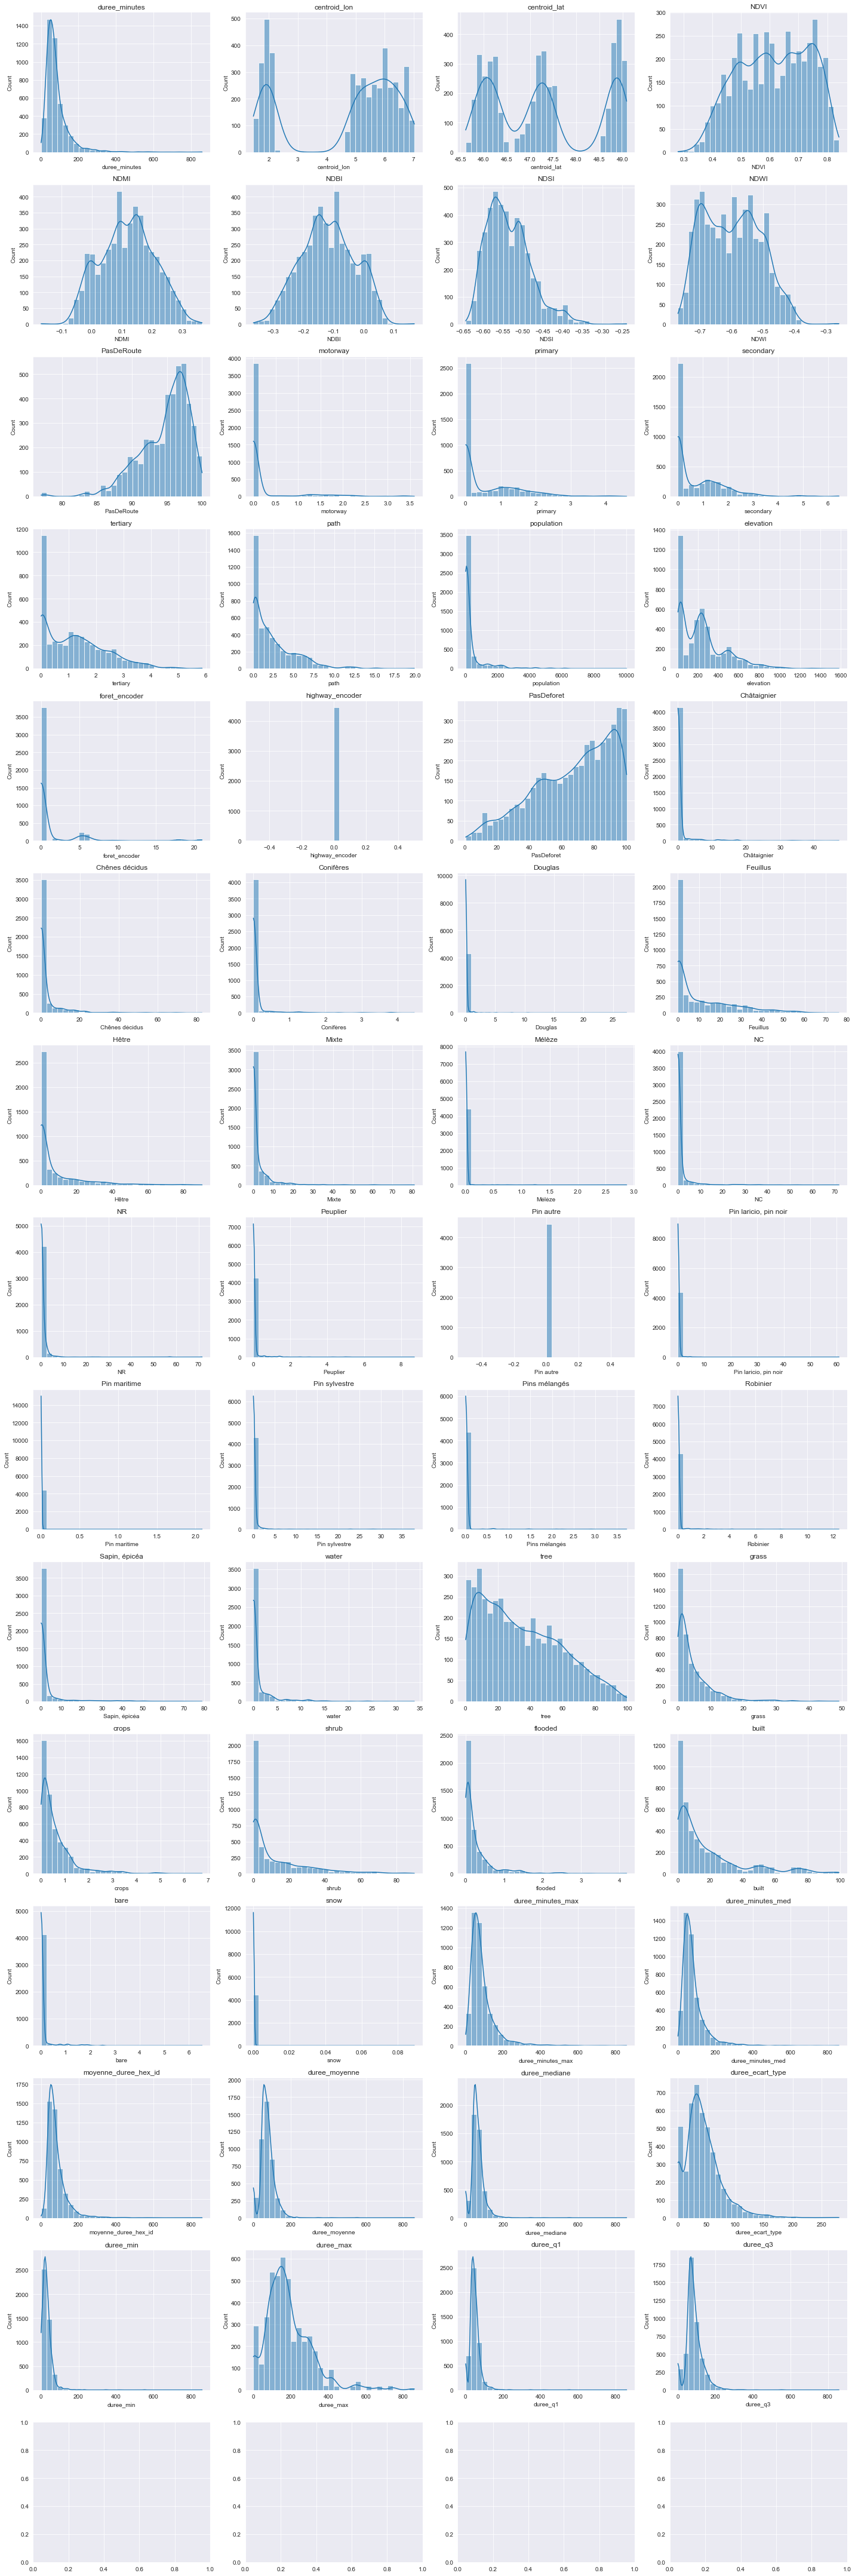

In [48]:
numerical_features = all_train.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(nrows=len(numerical_features)//4 + 1, ncols=4, figsize=(20, 4 * (len(numerical_features)//4 + 1)))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(all_train[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [49]:
numerical_features = all_train.select_dtypes(include=['number'])

desc_stats = numerical_features.describe().T
desc_stats["skewness"] = numerical_features.skew()
desc_stats["kurtosis"] = numerical_features.kurt()

Q1 = numerical_features.quantile(0.25)
Q3 = numerical_features.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numerical_features < (Q1 - 1.5 * IQR)) | (numerical_features > (Q3 + 1.5 * IQR))).sum()

desc_stats["outliers"] = outliers

print(desc_stats)

                        count        mean         std        min         25%  \
duree_minutes          4454.0   81.090636   64.523389   0.366667   43.633333   
centroid_lon           4454.0    4.653170    1.885225   1.463404    2.072047   
centroid_lat           4454.0   47.303722    1.148489  45.609951   46.190770   
NDVI                   4454.0    0.614029    0.121592   0.279866    0.512322   
NDMI                   4454.0    0.118087    0.088940  -0.167461    0.052004   
NDBI                   4454.0   -0.118087    0.088940  -0.364960   -0.180433   
NDSI                   4454.0   -0.534973    0.055638  -0.643715   -0.576638   
NDWI                   4454.0   -0.597005    0.089681  -0.769938   -0.675938   
PasDeRoute             4454.0   94.731880    3.524429  77.019427   92.544529   
motorway               4454.0    0.218699    0.619267   0.000000    0.000000   
primary                4454.0    0.587941    0.852138   0.000000    0.000000   
secondary              4454.0    0.77724

In [50]:
df_numeric = all_train.select_dtypes(include=[np.number])

missing_values = df_numeric.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("\n=== VALEURS MANQUANTES ===")
print(missing_values)


=== VALEURS MANQUANTES ===
Series([], dtype: int64)


In [51]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(all_train.dtypes)

hex_id                     object
saison_annee               object
duree_minutes             float64
centroid_lon              float64
centroid_lat              float64
NDVI                      float64
NDMI                      float64
NDBI                      float64
NDSI                      float64
NDWI                      float64
PasDeRoute                float64
motorway                  float64
primary                   float64
secondary                 float64
tertiary                  float64
path                      float64
population                float64
elevation                 float64
foret_encoder             float64
highway_encoder           float64
PasDeforet                float64
Châtaignier               float64
Chênes décidus            float64
Conifères                 float64
Douglas                   float64
Feuillus                  float64
Hêtre                     float64
Mixte                     float64
Mélèze                    float64
NC            

In [52]:
"""z_scores = (df.select_dtypes(include=np.number) - df.mean()) / df.std()
outliers = (z_scores.abs() > 3).sum()
print("Valeurs extrêmes (au-delà de 3 écarts-types) :")
print(outliers)

corr_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Matrice de corrélation entre les variables numériques")
plt.show()"""

'z_scores = (df.select_dtypes(include=np.number) - df.mean()) / df.std()\noutliers = (z_scores.abs() > 3).sum()\nprint("Valeurs extrêmes (au-delà de 3 écarts-types) :")\nprint(outliers)\n\ncorr_matrix = df.select_dtypes(include=np.number).corr()\n\nplt.figure(figsize=(12, 8))\nsns.heatmap(corr_matrix, annot=True, cmap=\'coolwarm\', fmt=\'.2f\', cbar=True)\nplt.title("Matrice de corrélation entre les variables numériques")\nplt.show()'

Valeurs manquantes :
Empty DataFrame
Columns: [Column, Missing Values, Percentage]
Index: []

Outliers détectés (duree_minutes) :
               hex_id    saison_annee  duree_minutes  centroid_lon  \
140   871f8202bffffff  Printemps 2015     367.333333      6.355079   
153   871f82036ffffff  Printemps 2017     319.733333      6.167080   
161   871f82045ffffff        Été 2018     326.916667      6.512011   
211   871f820aaffffff    Automne 2014     345.533333      6.233937   
233   871f820d5ffffff        Été 2015     297.833333      6.364719   
...               ...             ...            ...           ...   
4430  871fb6b51ffffff  Printemps 2019     602.950000      1.868801   
4432  871fb6b51ffffff  Printemps 2023     289.000000      1.868801   
4438  871fb6b55ffffff        Été 2019     363.900000      1.850006   
4464  871fb6b69ffffff    Automne 2020     315.858333      1.975344   
4475  871fb6b76ffffff        Été 2017     422.283333      1.782058   

      centroid_lat      NDVI 

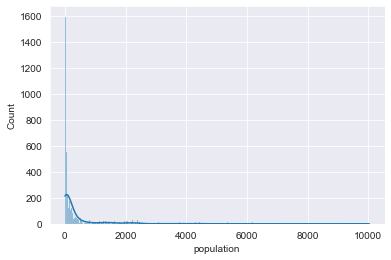


Encodage de la colonne : departement

Données après encodage de la colonne departement :
            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff        Été 2015      40.850000      6.350198     47.477082   
1  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   
2  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
3  871f80492ffffff        Été 2019     168.250000      6.350198     47.477082   
4  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...  duree_mediane  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...      66.966667   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...      66.966667   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...      58.450000   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...      91.800000   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  .

In [53]:
try:
    missing_values = all_train.isnull().sum()
    missing_percentage = (missing_values / len(all_train)) * 100
    missing_data = pd.DataFrame({'Column': missing_values.index, 'Missing Values': missing_values, 'Percentage': missing_percentage})
    missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

    print("Valeurs manquantes :")
    print(missing_data)
except Exception as e:
    print("Erreur lors de la vérification des valeurs manquantes :", e)

try:
    all_train['zscore_duree'] = zscore(all_train['duree_minutes'])

    outliers = all_train[all_train['zscore_duree'].abs() > 3]

    print("\nOutliers détectés (duree_minutes) :")
    print(outliers)
except Exception as e:
    print("Erreur lors de la détection des outliers :", e)

try:
    sns.histplot(all_train['population'], kde=True)
    plt.show()

    all_train['log_population'] = np.log1p(all_train['population'])

except Exception as e:
    print("Erreur lors de la transformation des variables continues :", e)

try:
    categorical_columns = ['departement', 'forêt_encoder', 'highway_encoder']

    for column in categorical_columns:
        if column in all_train.columns:
            print(f"\nEncodage de la colonne : {column}")
            all_train_encoded = pd.get_dummies(all_train, columns=[column], drop_first=True)

            print(f"\nDonnées après encodage de la colonne {column} :")
            print(all_train_encoded.head())
        else:
            print(f"\nLa colonne '{column}' n'existe pas dans le dataset.")

except Exception as e:
    print("Erreur lors de l'encodage des variables catégorielles :", e)

try:
    all_train_final = all_train_encoded.copy()

    print("\nFinalisation du dataset après transformations :")
    print(all_train_final.head())

except Exception as e:
    print("Erreur lors de la finalisation des transformations :", e)

In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Définition des variables cibles
target_columns = ['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']

# Séparation des features et des cibles pour train et test
X_train = all_train.drop(columns=target_columns)
y_train = all_train[target_columns]

X_test = all_test.drop(columns=target_columns)
y_test = all_test[target_columns]

# Suppression des colonnes non pertinentes
drop_columns = ["hex_id", "saison_annee", "geometry", "centroid", "hex_voisins"]
X_train = X_train.drop(columns=drop_columns)
X_test = X_test.drop(columns=drop_columns)

# Séparation des colonnes numériques et catégorielles
categorical_columns = ['departement']
numerical_columns = [col for col in X_train.columns if col not in categorical_columns]

# Préprocesseur avec encodage de 'departement' et normalisation des autres colonnes
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
    ])

# Transformation des données d'entraînement et de test
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Modèle XGBoost pour régression multi-output
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
multi_output_model = MultiOutputRegressor(xgb_model)
multi_output_model.fit(X_train, y_train)

# Prédiction et évaluation du modèle
y_pred = multi_output_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R²: {r2}')

KeyError: "['zscore_duree', 'log_population'] not in index"

In [57]:
print(set(all_train.columns) - set(all_test.columns))  # Colonnes présentes dans all_train mais absentes de all_test
print(set(all_test.columns) - set(all_train.columns))  # Colonnes présentes dans all_test mais absentes de all_train

{'log_population', 'zscore_duree'}
set()
